In [14]:
import pandas as pd # Import the pandas library

ames = pd.read_csv('AmesHousing.csv') # Read the AmesHousing.csv file into a pandas DataFrame

ames.head() # Display the first few rows of the DataFrame

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice
0,31770,6,5,1656,7,2010,215000
1,11622,5,6,896,5,2010,105000
2,14267,6,6,1329,6,2010,172000
3,11160,7,5,2110,8,2010,244000
4,13830,5,5,1629,6,2010,189900


In [15]:
# Create a new boolean column 'target value' indicating if SalePrice is >= 200000
ames['target value'] = (ames['SalePrice'] >= 200000)
# Display the first few rows of the DataFrame
ames.head()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice,target value
0,31770,6,5,1656,7,2010,215000,True
1,11622,5,6,896,5,2010,105000,False
2,14267,6,6,1329,6,2010,172000,False
3,11160,7,5,2110,8,2010,244000,True
4,13830,5,5,1629,6,2010,189900,False


In [16]:
# Group data by 'target value' and calculate the mean of each group.
ames.groupby('target value').mean()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice
target value,,,,,,,
False,9033.030185,5.483934,5.658715,1306.930380,6.032132,2007.803797,140245.305745
True,12762.062785,7.527397,5.339041,1951.664384,7.406393,2007.759132,275877.394977


In [17]:
import scipy.stats as stats # Import the scipy.stats module for t-test

# Separate data into two groups based on 'target value' column
group1 = ames[ames['target value'] == True] 
group2 = ames[ames['target value'] == False]

# Perform an independent samples t-test on 'Lot Area' for the two groups
print(stats.ttest_ind(group1['Lot Area'], group2['Lot Area']))

TtestResult(statistic=12.010357773110666, pvalue=1.793734747012678e-32, df=2928.0)


In [18]:
# Import the necessary library.  This line was missing in the original code.
import scipy.stats as stats

# Perform an independent samples t-test on 'Overall Qual'
print(stats.ttest_ind(group1['Overall Qual'], group2['Overall Qual']))
# Perform an independent samples t-test on 'Overall Cond'
print(stats.ttest_ind(group1['Overall Cond'], group2['Overall Cond']))
# Perform an independent samples t-test on 'Gr Liv Area'
print(stats.ttest_ind(group1['Gr Liv Area'], group2['Gr Liv Area']))
# Perform an independent samples t-test on 'TotRms AbvGrd'
print(stats.ttest_ind(group1['TotRms AbvGrd'], group2['TotRms AbvGrd']))
# Perform an independent samples t-test on 'Yr Sold'
print(stats.ttest_ind(group1['Yr Sold'], group2['Yr Sold']))

TtestResult(statistic=47.93751919037016, pvalue=0.0, df=2928.0)
TtestResult(statistic=-7.188296925907744, pvalue=8.290017633689768e-13, df=2928.0)
TtestResult(statistic=38.928767514080974, pvalue=1.5834591903793514e-267, df=2928.0)
TtestResult(statistic=23.619140019112713, pvalue=4.823274671819433e-113, df=2928.0)
TtestResult(statistic=-0.840632949411603, pvalue=0.4006222345273083, df=2928.0)


In [19]:
# Select columns 'Lot Area', 'Overall Qual', and 'target value' from the 'ames' DataFrame.
ames = ames[['Lot Area','Overall Qual','target value']]
# Display the first few rows of the modified DataFrame.
ames.head()

,Lot Area,Overall Qual,target value
0,31770,6,True
1,11622,5,False
2,14267,6,False
3,11160,7,True
4,13830,5,False


In [20]:
from sklearn.model_selection import train_test_split

# Assuming 'ames' is a pre-existing dataset.  This line splits it into training and testing sets.
train_data, test_data = train_test_split(ames)

In [21]:
import statsmodels.api as sm # Import the statsmodels library

dependent = train_data['target value'] # Define the dependent variable

independent = train_data[['Lot Area','Overall Qual']] # Define the independent variables
independent = sm.add_constant(independent) # Add a constant to the independent variables

In [22]:
# Import the necessary library.  This line was missing in the original code.
import statsmodels.api as sm

# Create a Logit model.
model = sm.Logit(
    dependent, 
    independent 
).fit()

Optimization terminated successfully.
         Current function value: 0.283979
         Iterations 8


In [23]:
# Print model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           target value   No. Observations:                 2197
Model:                          Logit   Df Residuals:                     2194
Method:                           MLE   Df Model:                            2
Date:                Tue, 01 Jul 2025   Pseudo R-squ.:                  0.5339
Time:                        17:43:00   Log-Likelihood:                -623.90
converged:                       True   LL-Null:                       -1338.6
Covariance Type:            nonrobust   LLR p-value:                4.171e-311
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -16.1281      0.703    -22.957      0.000     -17.505     -14.751
Lot Area         0.0002   1.56e-05     10.727      0.000       0.000       0.000
Overall Qual     2.0812      0.094     22.052      0.000       1.896       2.266
================================================================================
"""

In [24]:
# Assign the target variable from the test data.
test_actual = test_data['target value']

# Select the independent variables from the test data.
test_independent = test_data[['Lot Area','Overall Qual']]

# Add a constant term to the independent variables for the regression model.
test_independent = sm.add_constant(test_independent)

In [25]:
# Apply the model's prediction to the test data, considering values >= 0.5 as positive predictions.
test_predicted = model.predict(test_independent) >= 0.5
# Display the first few elements of the prediction results.
test_predicted.head()

2657    False
1012     True
120     False
2291    False
2897     True
dtype: bool

In [26]:
import sklearn.metrics as metrics # Import the metrics module from scikit-learn

cm = metrics.confusion_matrix(test_actual, test_predicted) # Compute the confusion matrix

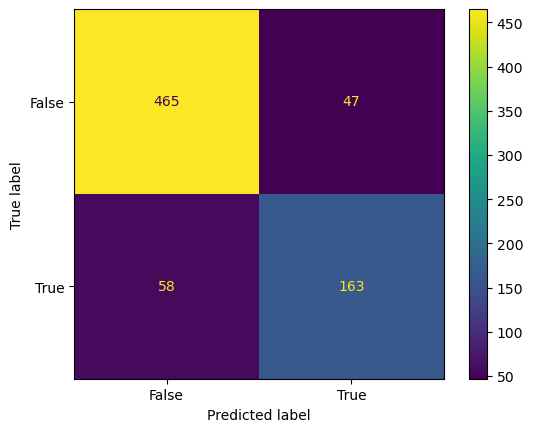

In [27]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming test_actual and test_predicted are pre-defined lists or arrays
# Calculate the confusion matrix
cm = confusion_matrix(test_actual, test_predicted, labels=list(set(test_actual))) #Use set to get unique labels.
# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(set(test_actual))) #Use set to get unique labels.
# Plot the confusion matrix
disp.plot()
# Show the plot
plt.show()